In [56]:
print(heatmap_data.min().min(), heatmap_data.max().max())
print(data.columns)
print(data.head())

31.16811257603358 31.175817122362073
Index(['position', 'wild-type', 'mutant', 'sequence', 'mutant_name', '0', '1'], dtype='str')
   position wild-type mutant  \
0         1         A      F   
1         1         A      H   
2         1         A      W   
3         1         A      Y   
4         1         A      G   

                                            sequence mutant_name        0  \
0  FAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPP...     mutant0  mutant0   
1  HAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPP...     mutant1  mutant1   
2  WAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPP...     mutant2  mutant2   
3  YAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPP...     mutant3  mutant3   
4  GAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPP...     mutant4  mutant4   

          1  
0  0.023538  
1  0.022100  
2  0.025707  
3  0.021818  
4  0.021945  


Heatmap Data Summary:
Shape: (6, 119)


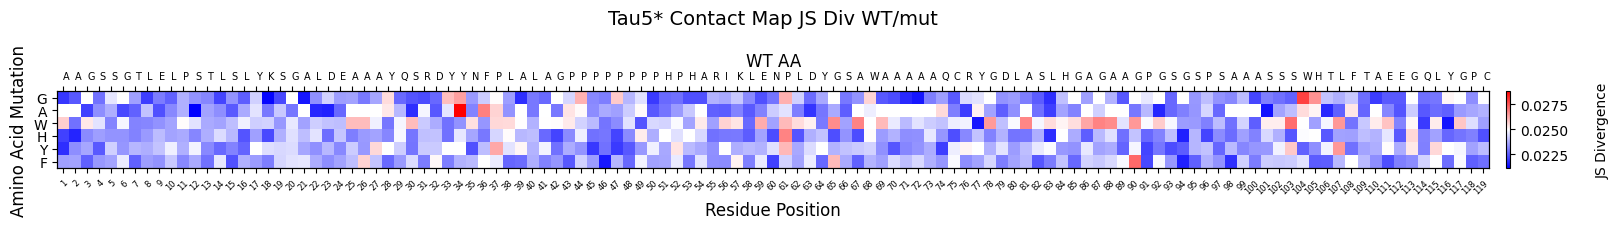

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

# Load the data with correct paths
rg_results = pd.read_csv('/Users/markhsia/robustelli_lab/ag_tau5_contact_js_results.csv')
mutants_info = pd.read_csv('/Users/markhsia/robustelli_lab/Naming/named_tau5_aromatic_and_ag.csv')

# Protein sequence
sequence = "AAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPPPPPPHPHARIKLENPLDYGSAWAAAAAQCRYGDLASLHGAGAAGPGSGSPSAAASSSWHTLFTAEEGQLYGPC"

# Merge the two dataframes
data = mutants_info.merge(rg_results, left_on='mutant_name', right_on='0', how='left')

# Create a pivot table with positions as columns and mutations as rows
positions = sorted(data['position'].unique())
#mutations = sorted([aa for aa in 'AGWHYF'])  # Standard amino acids
mutations = ['G', 'A', 'W', 'H', 'Y', 'F'] 

# Create an empty dataframe for the heatmap
heatmap_data = pd.DataFrame(index=mutations, columns=positions)

WT_ref = 2.3900

for idx, row in data.iterrows():
    pos = row['position']
    mut = row['mutant']
    comparator = row['1']
    
    heatmap_data.loc[mut, pos] = comparator

# Convert to numeric
heatmap_data = heatmap_data.astype(float)

# Create the visualization
fig, ax = plt.subplots(figsize=(22, 1))

# Create the heatmap manually
im = ax.imshow(heatmap_data.values, cmap='bwr', aspect='auto')
               #norm=mcolors.CenteredNorm(vcenter=0))

# Set ticks and labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

# Rotate the tick labels and set their alignment
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor", fontsize = 6, rotation = 45)

# Add sequence on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(np.arange(len(heatmap_data.columns)))
seq_labels = [sequence[pos-1] for pos in heatmap_data.columns]
ax2.set_xticklabels(seq_labels)
ax2.set_xlabel('WT AA', fontsize=12)
plt.setp(ax2.get_xticklabels(), ha="left", rotation_mode="anchor", fontsize = 7)

# Add colorbar with better positioning
cbar = plt.colorbar(im, ax=ax, pad=0.01, location='right')
cbar.set_label('JS Divergence', labelpad=20)

# Add labels and title
ax.set_xlabel('Residue Position', fontsize=12)
ax.set_ylabel('Amino Acid Mutation', fontsize=12)
ax.set_title('Tau5* Contact Map JS Div WT/mut', fontsize=14, pad=20)

plt.savefig('/Users/markhsia/robustelli_lab/tau5_mutation_R2R3sum_heatmap.png', dpi=300, bbox_inches='tight')

# Print summary statistics
print("Heatmap Data Summary:")
print(f"Shape: {heatmap_data.shape}")

Heatmap Data Summary:
Shape: (20, 56)


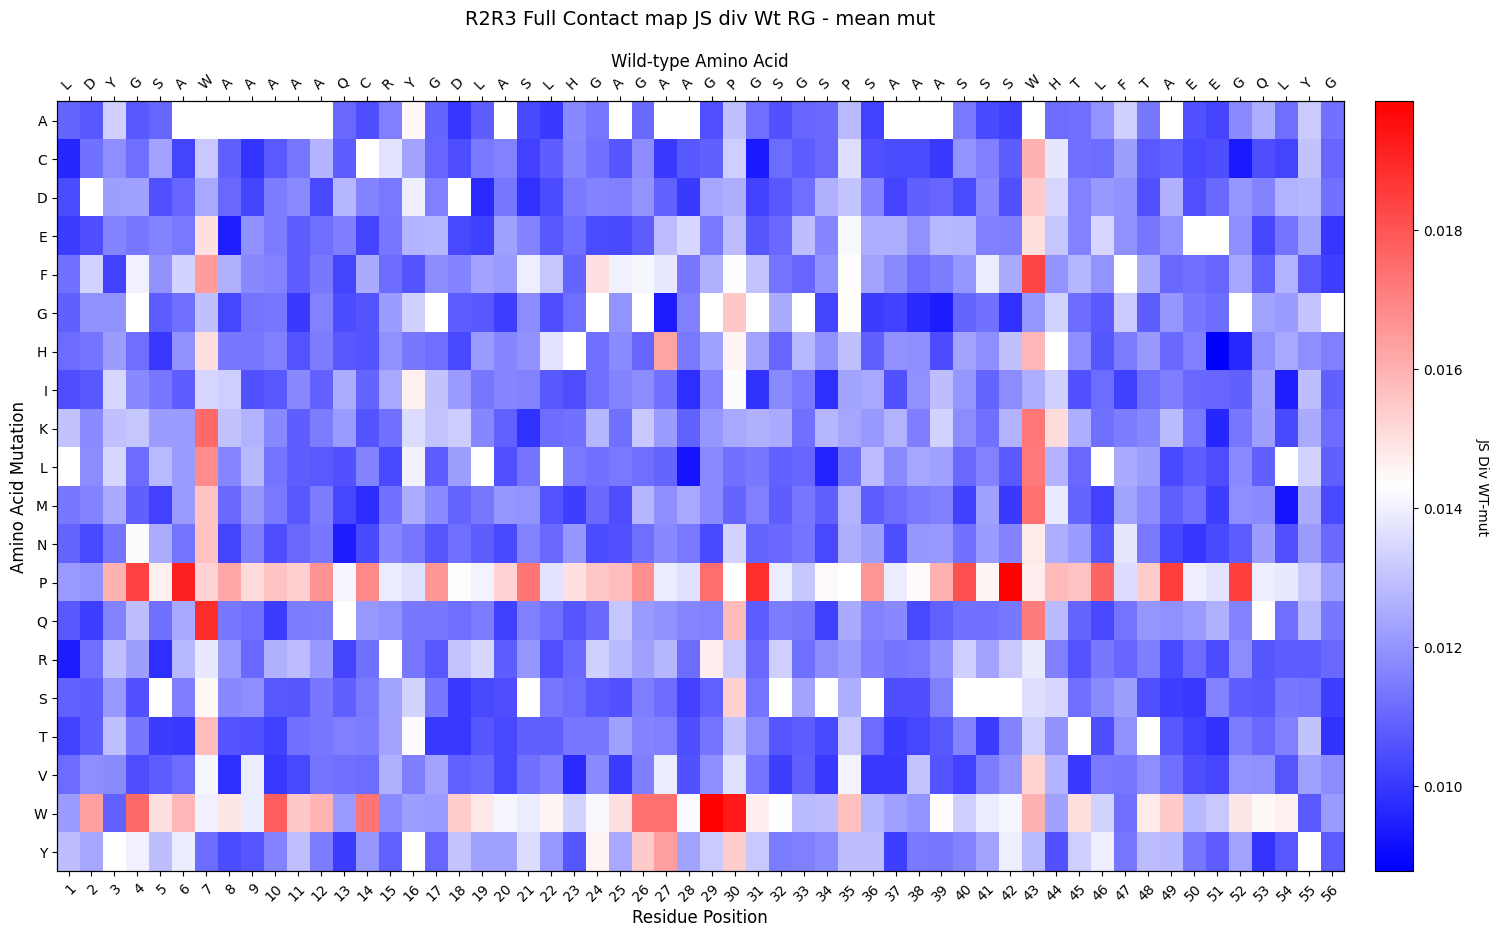

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load the data with correct paths
rg_results = pd.read_csv('/Users/markhsia/robustelli_lab/Results Files/R2R3_corrected/corrected_r2r3_contact_js_results.csv')
mutants_info = pd.read_csv('/Users/markhsia/robustelli_lab/naming/mutants_with_names.csv')

# Protein sequence
sequence = "LDYGSAWAAAAAQCRYGDLASLHGAGAAGPGSGSPSAAASSSWHTLFTAEEGQLYG"

# Merge the two dataframes
data = mutants_info.merge(rg_results, left_on='mutant_name', right_on='0', how='left')

# Create a pivot table with positions as columns and mutations as rows
positions = sorted(data['position'].unique())
mutations = sorted([aa for aa in 'ACDEFGHIKLMNPQRSTVWY'])  # Standard amino acids

# Create an empty dataframe for the heatmap
heatmap_data = pd.DataFrame(index=mutations, columns=positions)

WT_RG = 2.8420

for idx, row in data.iterrows():
    pos = row['position']
    mut = row['mutant']
    rg_change = row['1']
    #heatmap_data.loc[mut, pos] = WT_RG - rg_change
    heatmap_data.loc[mut, pos] = rg_change

# Convert to numeric
heatmap_data = heatmap_data.astype(float)

# Create the visualization
fig = plt.figure(figsize=(20, 10))
ax = plt.subplot(111)

# Create the heatmap manually
im = ax.imshow(heatmap_data.values, cmap='bwr', aspect='auto')
               #norm=mcolors.CenteredNorm(vcenter=0))

# Set ticks and labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

# Rotate the tick labels and set their alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add sequence on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(np.arange(len(heatmap_data.columns)))
seq_labels = [sequence[pos-1] for pos in heatmap_data.columns]
ax2.set_xticklabels(seq_labels)
ax2.set_xlabel('Wild-type Amino Acid', fontsize=12)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")

# Add colorbar with better positioning
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('JS Div WT-mut', rotation=270, labelpad=20)

# Add labels and title
ax.set_xlabel('Residue Position', fontsize=12)
ax.set_ylabel('Amino Acid Mutation', fontsize=12)
ax.set_title('R2R3 Full Contact map JS div Wt RG - mean mut', fontsize=14, pad=20)

plt.savefig('/Users/markhsia/robustelli_lab/mutation_rg_heatmap.png', dpi=300, bbox_inches='tight')

# Print summary statistics
print("Heatmap Data Summary:")
print(f"Shape: {heatmap_data.shape}")